In [1]:
# Test script 3

In [1]:
import xarray as xr
import os
import numpy as np

In [ ]:
def calc_PAF(AF, pop, region_mask):
    """
    AF: DataArray(lat, lon, year, samples)
    pop: DataArray(lat, lon)
    region_mask: DataArray(country, lat, lon) with 0/1 mask
    """

    # Numerator: weighted AF summed over lat/lon
    weighted_AF = (AF * pop)                     # (lat, lon, year, samples)
    numerator = (weighted_AF * region_mask).sum(dim=["lat", "lon"])  # (country, year, samples)

    # Denominator: population summed over lat/lon
    denominator = (pop * region_mask).sum(dim=["lat", "lon"])        # (country)

    PAF = numerator / denominator
    return PAF

In [2]:
def calc_global_PAF(AF, pop):
    """
    AF: DataArray(lat, lon, year, samples)
    pop: DataArray(lat, lon)
    region_mask: DataArray(country, lat, lon) with 0/1 mask
    """

    # Numerator: weighted AF summed over lat/lon
    weighted_AF = (AF * pop)                     # (lat, lon, year, samples)
    numerator = (weighted_AF).sum(dim=["lat", "lon"])  # (country, year, samples)

    # Denominator: population summed over lat/lon
    denominator = (pop).sum(dim=["lat", "lon"])        # (country)

    PAF = numerator / denominator
    return PAF

In [2]:
# === Path config ===
MASKS_DIR = "/glade/work/awells/air_quality/BMR/masks/country/"
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
BMR_DIR = "/glade/work/awells/air_quality/BMR/"

In [7]:
# Load country masks
mask_file = "GBD_Country_Masks_0.10.nc"
mask_path = os.path.join(MASKS_DIR, mask_file)
masks = xr.open_dataarray(mask_path)

# Load BMR for each country
bmr_file = "GBD_BMR_Country_COPD_newlabels_1990-2009.nc"
# bmr_file = "GBD_BMR_Country_Mask_COPD_1990-2009.nc"
bmr_path = os.path.join(BMR_DIR, bmr_file)
BMR = xr.open_dataarray(bmr_path)  # three quantiles

# Load population file
pop_file = "ssp2_coarse_grid_annual_2000-2100.nc"
pop_path = os.path.join(POP_DIR, pop_file)
population = xr.open_dataarray(pop_path)
pop = population.reindex_like(masks, method="nearest", tolerance=1e-9)

In [10]:
BMR.sel(quantile="mean").mean()

<xarray.DataArray 'BMR_by_country' ()> Size: 8B
array(23.0172103)
Coordinates:
    quantile  <U5 20B 'mean'

In [6]:
BMR.sel(quantile="mean").mean()

<xarray.DataArray ()> Size: 8B
array(0.00032823)
Coordinates:
    quantile  <U5 20B 'mean'
    region    <U26 104B ...

In [7]:
n_samples = 1000

# BMR from vizhub (GBD21)
bmr_mean = BMR.sel(quantile="mean")
bmr_lower = BMR.sel(quantile="lower")
bmr_upper = BMR.sel(quantile="upper")
bmr_std = (bmr_upper - bmr_lower) / (2 * 1.96)

bmr_samples = np.random.normal(bmr_mean, bmr_std, size=(n_samples, len(BMR.country)))
bmr_da = xr.DataArray(
    bmr_samples,
    dims=["samples", "country"],
    coords={"samples": np.arange(n_samples),
            "country": BMR.country}).astype("float32")

In [24]:
da = xr.open_dataarray("/glade/derecho/scratch/awells/air_quality/CESM2/mortality/Attributable_fraction_CESM2_SSP245_G6_01_2020.nc")

OSError: [Errno -101] NetCDF: HDF error: '/glade/derecho/scratch/awells/air_quality/CESM2/mortality/Attributable_fraction_CESM2_SSP245_G6_01_2020.nc'

In [11]:
bmr = bmr_da.mean("country")

In [18]:
# Calculate population weighted AF and mortality
PAF = calc_PAF(da.chunk({"samples": 10}), pop.sel(year=2020))
M = bmr * PAF

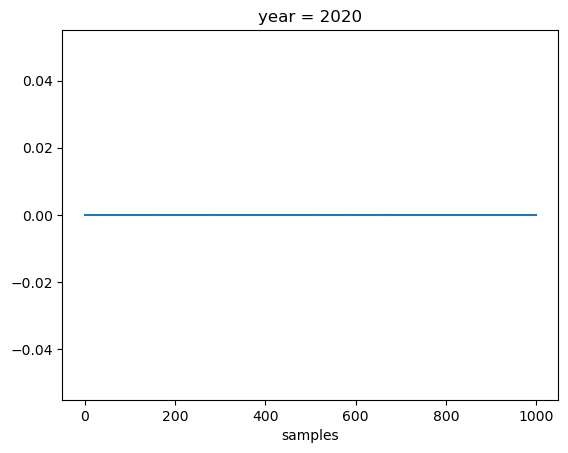

In [23]:
da.mean(dim=("lat","lon")).plot()

In [9]:
# mean over samples
M_mean = M.mean(dim="samples").chunk(-1)
# percentiles for 95% CI
M_lower = M.quantile(0.025, dim="samples").chunk(-1)
M_upper = M.quantile(0.975, dim="samples").chunk(-1)

M_summary = xr.Dataset({
    "M_mean": M_mean.astype("float32").drop_vars("year"),
    "M_lower95": M_lower.astype("float32").drop_vars("quantile"),
    "M_upper95": M_upper.astype("float32").drop_vars("quantile")
})

In [14]:
SAVE_DIR = "/glade/derecho/scratch/awells/air_quality/CESM2/mortality"

out_file = "Global_mortality_CESM2_SSP245_G6_01_2020.nc"
out_path = os.path.join(SAVE_DIR, out_file)
M.to_netcdf(out_path)

/glade/work/awells/conda-envs/my-env/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in multiply
  return self.func(*new_argspec)
/glade/work/awells/conda-envs/my-env/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in multiply
  return self.func(*new_argspec)


In [15]:
M = xr.open_dataarray(out_path)

In [17]:
M.mean()

<xarray.DataArray ()> Size: 8B
array(-inf)
Coordinates:
    year     int64 8B ...